# 02 -- Vectors and vector spaces

| question | answer |
|---|---|
| What physics problem? | Forces and fields have magnitude and direction. |
| What mathematics? | Vector spaces, inner product, cross product, projection, orthonormal bases. |
| What algorithm? | Dot and cross products; modified Gram-Schmidt orthonormalization. |
| What software? | NumPy arrays; physkit.linalg.gram_schmidt; SymPy matrices. |
| What experiment? | A force sensor reports three orthogonal components. |
| What engineering application? | A vector is a contiguous array; SIMD lanes process its components. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
import physkit
from physkit import constants as C, units as U, linalg as la
from physkit.plotting import use_style
use_style()
torch = physkit.optional_torch()            # None if PyTorch is unavailable; NumPy stays authoritative
sp.init_printing()
print("physkit", physkit.__version__, "| numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

physkit 0.1.0 | numpy 2.4.6 | torch: absent (optional)


## English explanation

A vector carries a magnitude and a direction. Physical vectors -- force, velocity, electric
field -- add tip-to-tail and scale by real numbers, which is exactly the definition of a vector
space. Two operations extract geometry from components: the **inner (dot) product** gives lengths and
angles, and the **cross product** gives the perpendicular and the area of the spanned parallelogram.
Orthonormal bases let any vector be written as independent coordinates.

Subject-verb-object: the field points somewhere; the dot product measures alignment; the basis names
the coordinates.

## Mathematical derivation

For $\mathbf a,\mathbf b\in\mathbb R^3$, the dot product $\mathbf a\cdot\mathbf
b=\sum_i a_i b_i=|\mathbf a||\mathbf b|\cos\theta$ and the cross product magnitude
$|\mathbf a\times\mathbf b|=|\mathbf a||\mathbf b|\sin\theta$. Squaring and adding gives the
**Lagrange identity** $(\mathbf a\cdot\mathbf b)^2+|\mathbf a\times\mathbf b|^2=|\mathbf
a|^2|\mathbf b|^2$. The projection of $\mathbf a$ onto $\mathbf b$ is
$\mathrm{proj}_{\mathbf b}\mathbf a=\frac{\mathbf a\cdot\mathbf b}{\mathbf b\cdot\mathbf
b}\mathbf b$, the building block of Gram-Schmidt.

## Dimensions and SI units

Every component of a force vector is a force (newtons), and so is its magnitude. The dot product
of two forces would carry units of $\mathrm{N}^2$; a projection stays in newtons. `physkit.units`
confirms a component is a force and that the magnitude keeps that dimension.

In [2]:
Fx = U.Quantity(3.0, U.FORCE); Fy = U.Quantity(4.0, U.FORCE)
mag = (Fx*Fx + Fy*Fy) ** 0.5          # sqrt(Fx^2 + Fy^2)
print("force component dim:", Fx.dim, "| magnitude dim:", mag.dim, "| |F| =", mag.value, "N")
assert mag.dim == U.FORCE

force component dim: L^1 M^1 T^-2 | magnitude dim: L^1 M^1 T^-2 | |F| = 5.0 N


## SymPy derivation

SymPy verifies the Lagrange identity symbolically for general components.

In [3]:
a = sp.Matrix(sp.symbols('a1 a2 a3'))
b = sp.Matrix(sp.symbols('b1 b2 b3'))
dot = (a.T*b)[0]
cross = a.cross(b)
lhs = dot**2 + (cross.T*cross)[0]
rhs = (a.T*a)[0] * (b.T*b)[0]
assert sp.simplify(lhs - rhs) == 0
print("Lagrange identity (a.b)^2 + |axb|^2 = |a|^2 |b|^2 verified symbolically")

Lagrange identity (a.b)^2 + |axb|^2 = |a|^2 |b|^2 verified symbolically


## NumPy implementation

In [4]:
a = np.array([3.0, 4.0, 0.0]); b = np.array([1.0, 0.0, 0.0])
dot = float(a @ b)
angle = np.degrees(np.arccos(dot / (np.linalg.norm(a)*np.linalg.norm(b))))
proj = (dot / (b @ b)) * b
print(f"a.b = {dot} | |a| = {np.linalg.norm(a)} | angle(a,b) = {angle:.1f} deg")
print(f"projection of a onto b = {proj}")

# orthonormal basis from three random vectors (reuse physkit.linalg)
rng = np.random.default_rng(0)
Q = la.gram_schmidt(rng.standard_normal((3, 3)))
print("Gram-Schmidt basis orthonormal:", np.allclose(Q.conj().T @ Q, np.eye(3)))

a.b = 3.0 | |a| = 5.0 | angle(a,b) = 53.1 deg
projection of a onto b = [3. 0. 0.]
Gram-Schmidt basis orthonormal: True


## Pandas tables

In [5]:
vs = {"e_x": [1,0,0], "e_y": [0,1,0], "a": [3,4,0], "d": [1,1,1.0]}
rows = []
for name, v in vs.items():
    v = np.array(v, float)
    rows.append({"vector": name, "norm": round(np.linalg.norm(v), 4),
                 "angle_to_x_deg": round(np.degrees(np.arccos(v[0]/np.linalg.norm(v))), 1)})
print(pd.DataFrame(rows).to_string(index=False))

vector   norm  angle_to_x_deg
   e_x 1.0000             0.0
   e_y 1.0000            90.0
     a 5.0000            53.1
     d 1.7321            54.7


## Matplotlib plots

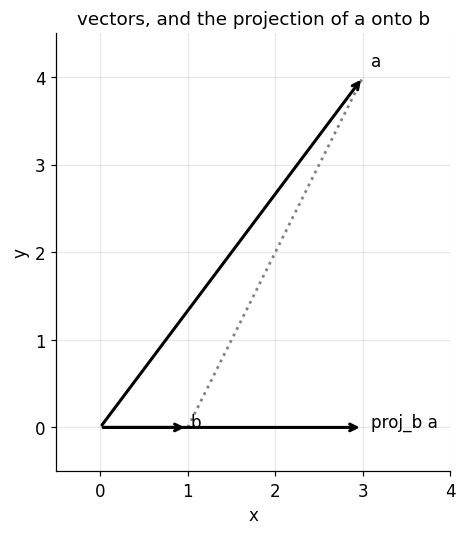

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for v, lab in [(a, "a"), (b, "b"), (proj, "proj_b a")]:
    ax.annotate("", xy=(v[0], v[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", lw=2))
    ax.text(v[0]*1.03, v[1]*1.03, lab)
ax.plot([b[0], a[0]], [b[1], a[1]], ":", color="gray")
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4.5); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("vectors, and the projection of a onto b")
plt.tight_layout(); plt.show()

## PyTorch (optional)

In [7]:
if torch is not None:
    at, bt = torch.tensor(a), torch.tensor(b)
    print("torch dot:", float(at @ bt), "| torch cross:", torch.linalg.cross(at, bt).tolist())
else:
    print("PyTorch absent -- NumPy dot/cross above are authoritative.")

PyTorch absent -- NumPy dot/cross above are authoritative.


## Exercises

1. Verify numerically that the cross product is anti-commutative, $\mathbf a\times\mathbf
   b=-\mathbf b\times\mathbf a$, and that $\mathbf a\cdot(\mathbf a\times\mathbf b)=0$.
2. Given a plane's normal $\mathbf n$, decompose a vector into components parallel and perpendicular
   to the plane using projection.
3. Show that Gram-Schmidt applied to a linearly dependent set raises; explain the geometric meaning.

## Engineering applications

A three-axis **sensor** delivers a force or field as three numbers; **firmware** stores them as
a contiguous array, and a **SIMD** unit computes the dot product across lanes in one instruction.
Orthonormal bases underlie coordinate transforms in **DSP** and the change-of-basis a **GPU** applies
to render or rotate data. The vector abstraction is the same in the physics and in the memory layout.

Summary (subject-verb-object): the sensor reports components; the dot product measures alignment;
Gram-Schmidt builds the basis; the array stores the vector.